# First ml model

- in Linear Regression..
- y = mx+c , here m and c is decided during the model training..


- Slope : Rate of change of y with respect to x when x is increased or decreased by 1 unit..

- Here m = 5 and c = 20 here marks changes by 5 marks when study hours increase or decrease by 1 unit..



- conclusion : for Every 1 squre feet of area increase or decrease in the plot.. the house price will increase/Decrease  by Rs 5000 


- Slope can calculated..using this  : cov(x,y) / var(x) 

- where var(x)  =  Summation (xi - x^bar) ** 2 / n

- cov(x,y) = (summation (xi - x^bar) * (yi - y^bar) ) / n 

- so Slope  =  Summation(xi - x^bar) * (yi - y^bar) ) / Summation(xi - x^bar) ** 2

- Intercept = Y^bar - (slope * X ^bar) jj 

## Loading dataset

In [87]:
import pandas as pd

df = pd.read_csv("../datasets/Salary_Data.csv")
df.head(2)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0


## Data Cleaning

In [88]:
# df.drop_duplicates()

In [89]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [90]:
df.isnull().count() 

YearsExperience    30
Salary             30
dtype: int64

## Data Preparation

### Separate the data into x and y

In [91]:
# y = df['Salary']
# y

# x = df.drop('Salary', axis = 1)
# x

 #  OR 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # Here LinearRegression , it is a class.. and its property can be accessed using objects.


X = df[['YearsExperience']]  # X should be present in the 2D only..
Y = df['Salary']

result = train_test_split(X,Y,test_size=0.8)  # 80% for the model testing we have given , so it is more test data , and less train data 
# we should have 80% train and 20% test or 70-30, 90-100

result   # returns a list of 4 different outputs



[    YearsExperience
 6               3.0
 23              8.2
 0               1.1
 28             10.3
 24              8.7
 4               2.2,
     YearsExperience
 1               1.3
 20              6.8
 5               2.9
 29             10.5
 17              5.3
 25              9.0
 11              4.0
 10              3.9
 21              7.1
 19              6.0
 14              4.5
 2               1.5
 12              4.0
 26              9.5
 8               3.2
 3               2.0
 27              9.6
 16              5.1
 7               3.2
 15              4.9
 13              4.1
 18              5.9
 9               3.7
 22              7.9,
 6      60150.0
 23    113812.0
 0      39343.0
 28    122391.0
 24    109431.0
 4      39891.0
 Name: Salary, dtype: float64,
 1      46205.0
 20     91738.0
 5      56642.0
 29    121872.0
 17     83088.0
 25    105582.0
 11     55794.0
 10     63218.0
 21     98273.0
 19     93940.0
 14     61111.0
 2      37731.0
 12    

In [92]:
result[0]

,YearsExperience
6,3.0
23,8.2
0,1.1
28,10.3
24,8.7
4,2.2


In [93]:
result[1]

,YearsExperience
1,1.3
20,6.8
5,2.9
29,10.5
17,5.3
25,9.0
11,4.0
10,3.9
21,7.1
19,6.0


In [94]:
print(len(result))

4


### Data splitting into train and test

- 80% and 20%
- 70% and 30%
- 90% and 10%

- we split data because we want to evaluate the model , with the help of test data , because it is unseen data

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

# here test_size =0.2 so  the test data is 20% train data is 80% -> this is correct ratio.
# Here the 80% data keeps on changing everytime for training , to fix that we hve a variable called random_state = 42 which fixes the data 
# randomness...

# first two values the function returns belongs to X
# last two values the function returns belOngs to Y

X_train
#2D

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [96]:
X_train.shape

(24, 1)

In [97]:
X_test.shape

(6, 1)

In [98]:
y_train
# 1D

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [99]:
y_train.shape

(24,)

In [100]:
y_test.shape

(6,)

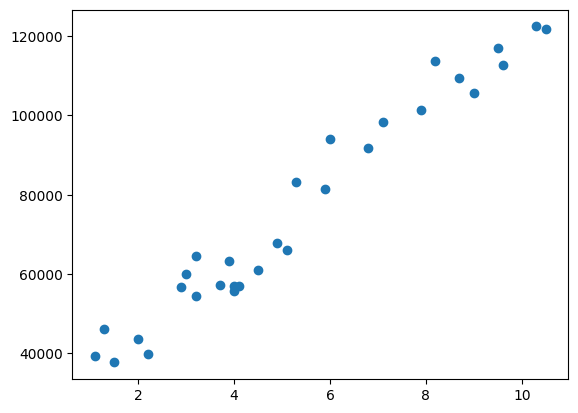

In [101]:
# to confirm whether the relation is linear or non-linear

import matplotlib.pyplot as plt

plt.scatter(X,Y)
plt.show()

<Axes: title={'center': 'Salary Increase Chart using Line Plot'}, xlabel='YearsExperience', ylabel='Salary'>

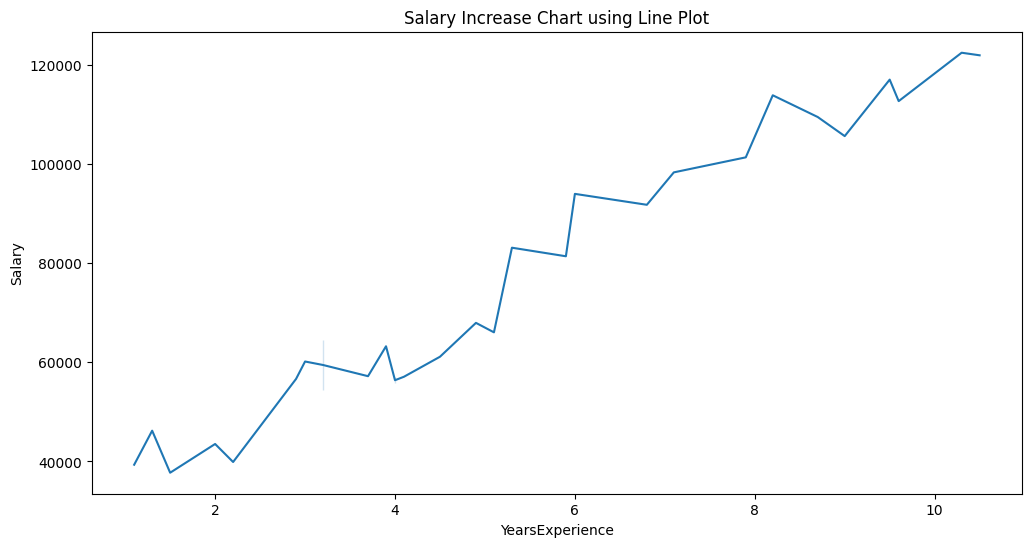

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.title("Salary Increase Chart using Line Plot")
sns.lineplot(data=df,x=df.YearsExperience,y=df.Salary)

In [103]:
df.corr()*100  

#finding the correlation

,YearsExperience,Salary
YearsExperience,100.000000,97.824162
Salary,97.824162,100.000000


## Model Building

### Training the model

In [104]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression() 

# it is a object of Class LinearRegression

#train the model
# here the X should be used in 2D form and then Y should be 1D only..


model_lr.fit(X_train, y_train)

 # fit() method used to learn the pattern from labelled data , it basically find the best fit line of the linear regression and
            # then it finds the mx+c for the line..


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [105]:
# To find the Intercept of the best fit line..
model_lr.intercept_

# so this is the initial  salary when there is no experience => 25321

np.float64(25321.583011776813)

**Conclusion:**
- Intercept values is 25321.583011776813
- When YearExp is Zero Salary is 25321.583011776813
- Fresher Salary is 25321.583011776813

In [106]:
#slope

model_lr.coef_

# Weight :
# It tells the importance of Features

array([9423.81532303])

**Conclusion:**
- Slope = 9423.81532303
- **So** when the feature increases or decreases (changes) by 1 unit the output changes by 9423
- **_Example:_** if years of experience increases by 1 year (If our dataset yearof_experience column is having 1,2,3, .. (1 unit = 1 year )like this values, then each time a year of experince increases by 1 -> the salary increases by 9423)

### Applying and Evaluating the model  ( 01/05/26 )

1. **fit():** 
    > model.fit(x_train, y_train)
    - this method is used to train the model  
    - learn the pattern 
    - find m and c value 
    - it is also used to find the best fit line 

2. **predict():**
    - used for evaluation
    - it is not only for future prediction 
    - it accepts only one argument that is x_train or x_test (only the inputs)
    - we have to evaluate for both train and test
    - train_data -> to check how well model learned the pattern
    - test_data -> to check how the model is going to perform on an unseen data

        __**Error:**__
        - >actual_value - predicted_value
        - mistake done by the model
        - we can find the errors only after predict()

3. **score()**:
    - used to find the accuracy of the model

#### Predicting X_train  (training data)

In [107]:
# predicted values
y_lr_train_pred = model_lr.predict(X_train)
y_lr_train_pred

# then we can compare actual values and predicted values

array([122386.880839  , 107308.77632215,  63016.8443039 ,  35687.77986711,
        46053.97672244,  73383.04115923,  52650.64744857,  63959.2258362 ,
        63016.8443039 ,  99769.72406372,  37572.54293172,  39457.30599632,
       110135.92091906,  44169.21365784,  92230.6718053 , 114847.82858057,
        80922.09341766, 124271.6439036 ,  89403.52720839,  55477.79204548,
        62074.4627716 ,  67728.75196542,  81864.47494996,  53593.02898087])

#### importing and evaluating the model using metrics

In [108]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [109]:
r2_score(y_train, y_lr_train_pred)

0.9645401573418146

In [110]:
# mean_absolute_error()

In [111]:
# errors = actual_value - predicted_value
errors = y_train - y_lr_train_pred 
errors

28        4.119161
24     2122.223678
12    -6059.844304
0      3655.220133
4     -6162.976722
16    -7354.041159
5      3991.352551
13    -6878.225836
11    -7222.844304
22     1532.275936
1      8632.457068
2     -1726.305996
25    -4553.920919
3      -644.213658
21     6042.328195
26     2121.171419
18      440.906582
29    -2399.643904
20     2334.472792
7     -1032.792045
10     1143.537228
14    -6617.751965
19    12075.525050
6      6556.971019
Name: Salary, dtype: float64

**Another way of model evaluation or to verify the model performance**
- we can use **_scatter plot_** for train and test data separately instead of the model evaluation metrics.

**1. Train Data:**
> plt.scatter(X_train,y_train)

> plt.scatter(X_train, y_lr_train_pred)

**2. Test Data:**
>plt.scatter(X_test,y_test)

> plt.scatter(X_test, y_lr_test_pred)

Text(0, 0.5, 'Salary')

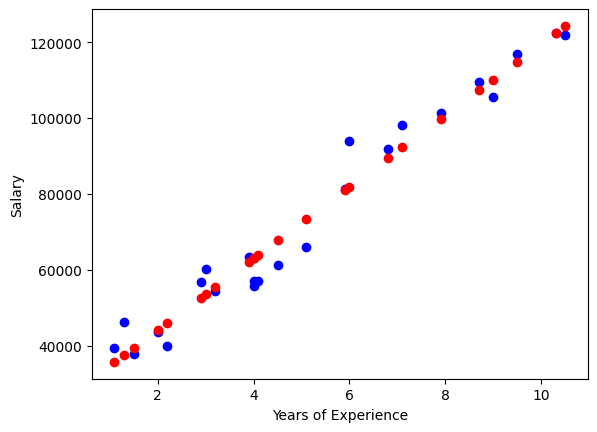

In [112]:
import matplotlib.pyplot as plt 

plt.scatter(X_train,y_train, color="b")
plt.scatter(X_train, y_lr_train_pred, color='red')
plt.xlabel('Years of Experience')
plt.ylabel("Salary")

#### Predicting X_test  (testing data)

In [113]:
# GIVING OUR OWN INPUT

x_testing = [[10]]
y_testing = model_lr.predict(x_testing)
y_testing

d:\PySpiders\pyspiders -ML\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([119559.73624209])

In [114]:
y_lr_test_pred = model_lr.predict(X_test)
y_lr_test_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [115]:
# errors = actual_value - predicted_value
errors = y_test - y_lr_test_pred 
errors

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64

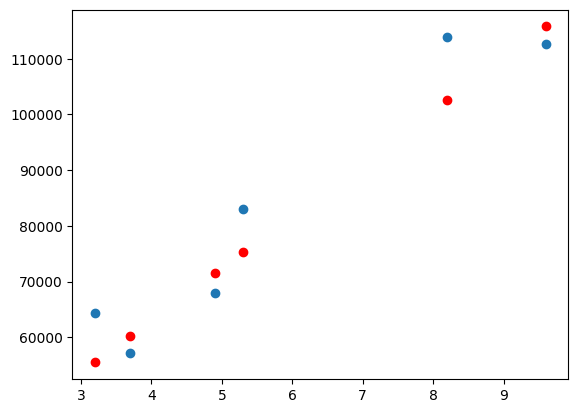

In [ ]:
import matplotlib.pyplot as plt 

plt.scatter(X_test,y_test)
plt.scatter(X_test, y_lr_test_pred, color="red")

# sometimes using scatter plot we cannot conclude so easily so we use correlation matrix and get the relation between two columns
# or we can use score()

#### Train and test Score


In [117]:
train_score = model_lr.score(X_train, y_train)  # this is using r2_score internally to compare the training data and the predicted training data, it peroforms an self.predict(x)
train_score

0.9645401573418146

In [118]:
test_score = model_lr.score(X_test, y_test)
test_score

# same thing here also this is using r2_score internally to compare the training data and the predicted training data, it peroforms an self.predict(x)

0.9024461774180497

**Building model steps:**
- confirm the data is linear or not using scatter plot 
- using correlation find the relation between them
- then train the model and go on 

## Evaluating the model again (using MSE, RMSE, MAE, R2_SCORE)

In [119]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [120]:
# mse 

#### checking the overfitting/ underfit/ goodfit

In [121]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [123]:
train_r2 = r2_score(y_train, y_lr_train_pred)

test_r2 = r2_score(y_test, y_lr_test_pred)

print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

Train R2 : 0.9645401573418146
Test R2  : 0.9024461774180497


**conclusion: (overfitting / underfitting/ goodfit)**
- train data r2_score = 96
- test data r2_score = 90
- since model is performing well on both the data(train and test) - model is a **goodfit**
